# Práctica: librosa en Python

**Materia:** Recuperación de la Información

`librosa` es una librería de Python para **análisis de audio y música**. Este notebook explica su funcionamiento y muestra un ejemplo simple ejecutable.

## ¿Para qué sirve?

`librosa` permite cargar archivos de audio y extraer **características acústicas**: forma de onda, espectrograma, tempo, tono (pitch), timbre (MFCC), energía, entre otras. Se usa mucho en recuperación de información musical (Music Information Retrieval), clasificación de audio, reconocimiento de voz y como paso previo a modelos de machine learning sobre sonido.

## ¿Cómo funciona?

1. **Carga de audio:** `librosa.load` lee un archivo de audio y lo convierte en un arreglo de NumPy con la señal (amplitud en el tiempo) más su frecuencia de muestreo (sample rate).
2. **Transformada de Fourier de corto tiempo (STFT):** la señal se divide en pequeñas ventanas de tiempo y a cada una se le aplica una Transformada de Fourier, obteniendo cuánta energía hay en cada frecuencia a lo largo del tiempo (esto es el **espectrograma**).
4. **Extracción de características:** sobre ese espectrograma se calculan métricas como los **MFCC** (coeficientes cepstrales en las frecuencias de Mel, que resumen el timbre del sonido), la **tasa de cruces por cero**, el **centroide espectral** o el **tempo** (pulsaciones por minuto), que sirven para comparar, clasificar o indexar sonidos.

## ¿Qué tipo de análisis/consultas se pueden realizar?

- Cargar audio y conocer su **duración** y **frecuencia de muestreo** (`librosa.load`, `librosa.get_duration`).
- Calcular y graficar la **forma de onda** (`librosa.display.waveshow`).
- Calcular el **espectrograma** (`librosa.stft`, `librosa.amplitude_to_db`).
- Extraer **MFCC** (`librosa.feature.mfcc`), usados para reconocimiento de voz/instrumentos.
- Calcular la **tasa de cruces por cero** (`librosa.feature.zero_crossing_rate`), útil para distinguir sonidos tonales de ruidosos.
- Calcular el **centroide espectral** (`librosa.feature.spectral_centroid`), relacionado con el "brillo" del sonido.
- Estimar el **tempo y los beats** (`librosa.beat.beat_track`).

## Ejemplo simple

Como no contamos con un archivo de audio real, generamos una señal sintética (un tono que combina dos frecuencias, simulando una nota musical) para poder demostrar cada función de forma reproducible.

In [6]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf

sr = 22050  # frecuencia de muestreo estandar en librosa
duracion = 3.0
t = np.linspace(0, duracion, int(sr*duracion), endpoint=False)

# Señal sintetica: nota La4 (440 Hz) + su tercer armonico, con una leve envolvente
señal = 0.5*np.sin(2*np.pi*440*t) + 0.2*np.sin(2*np.pi*880*t)
envolvente = np.clip(np.linspace(0, 1, len(t))*3, 0, 1) * np.clip(np.linspace(1, 0, len(t))*3, 0, 1)
señal = (señal * envolvente).astype(np.float32)

sf.write('tono_demo.wav', señal, sr)
print('Archivo generado: tono_demo.wav')

y, sr = librosa.load('tono_demo.wav', sr=None)
duracion_real = librosa.get_duration(y=y, sr=sr)
print(f'Frecuencia de muestreo: {sr} Hz')
print(f'Duracion: {duracion_real:.2f} segundos')
print(f'Numero de muestras: {len(y)}')

Archivo generado: tono_demo.wav
Frecuencia de muestreo: 22050 Hz
Duracion: 3.00 segundos
Numero de muestras: 66150


### Forma de onda

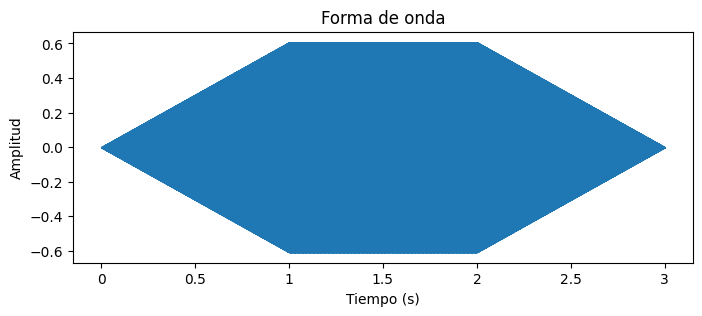

In [7]:
plt.figure(figsize=(8,3))
librosa.display.waveshow(y, sr=sr)
plt.title('Forma de onda')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

### Espectrograma (STFT)

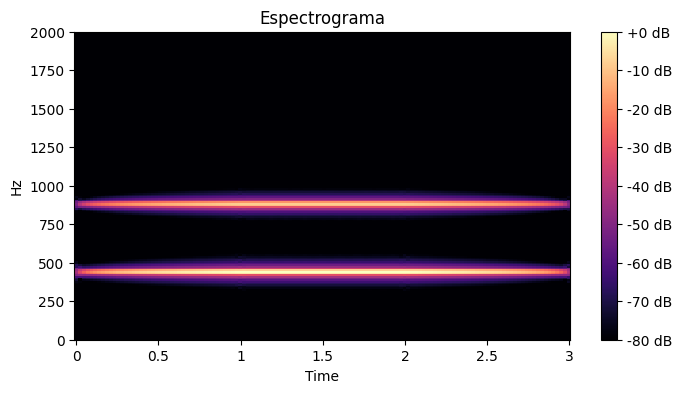

In [8]:
S = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(8,4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma')
plt.ylim(0, 2000)
plt.show()

### MFCC (coeficientes cepstrales en frecuencias de Mel)

Forma de la matriz MFCC (coeficientes x frames): (13, 130)


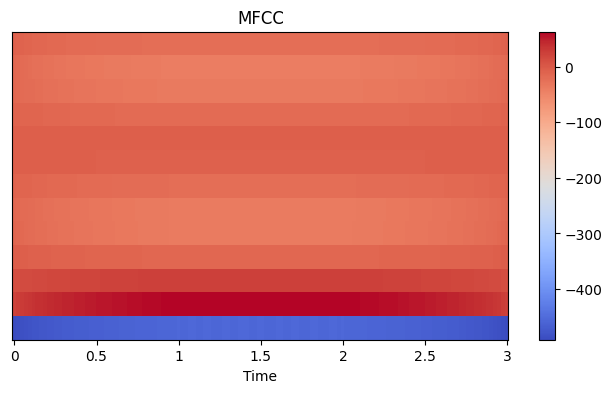

In [9]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print('Forma de la matriz MFCC (coeficientes x frames):', mfccs.shape)

plt.figure(figsize=(8,4))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title('MFCC')
plt.show()

### Otras características: cruces por cero, centroide espectral y tempo

In [10]:
zcr = librosa.feature.zero_crossing_rate(y)
centroide = librosa.feature.spectral_centroid(y=y, sr=sr)

print(f'Tasa promedio de cruces por cero: {zcr.mean():.4f}')
print(f'Centroide espectral promedio: {centroide.mean():.1f} Hz')

tempo, beats = librosa.beat.beat_track(y=y, sr=sr)
tempo_val = float(np.atleast_1d(tempo)[0])
print(f'Tempo estimado: {tempo_val:.1f} BPM (referencial; la señal es un tono sostenido, no musica con ritmo real)')

Tasa promedio de cruces por cero: 0.0395
Centroide espectral promedio: 572.9 Hz
Tempo estimado: 0.0 BPM (referencial; la señal es un tono sostenido, no musica con ritmo real)


## Conclusión

A partir de una señal de audio, `librosa` permite pasar de una simple onda a un conjunto de características numéricas (espectrograma, MFCC, centroide, tempo) que resumen su contenido y que pueden usarse para comparar, buscar o clasificar sonidos, tal como una base de datos indexa texto para poder consultarlo.